# 定理4　苫米地臨場感加重定理 — 数値で見る例

> **この notebook の位置づけ。** 数値シミュレーション（説明用のトイ例）で、証明ではありません。
> Lean で確かめた範囲は最後の「Lean との対応」に書きます。原文の主張・この例が見せること・仏教的な読み（解釈）は別の見出しに分けます。

## 1. 定理4は何を言っているのか

### 原文の主張

定理1〜3の地形 $V_0$ は固定されていました。定理4は、**「どれだけリアルに感じるか（臨場感）」が地形そのものを変形する** と述べます。

* $P\in[0,1]$：**臨場感**（ある対象をどれだけリアルに感じているか）。
* $Q\in[-1,1]$：その対象の **価値の符号**（$Q>0$：引かれる／$Q<0$：避ける）。
* $\kappa>0$：臨場感が地形を曲げる強さ。

実効的な地形（**実効コスト**）を

$$
\tilde V \;=\; V_0-\kappa\,P\,Q
$$

とし、Ego はこの $\tilde V$ について合計最小のプランで動きます。

$$
\pi_c^{P}=\arg\min_{u(\cdot)}\int\tilde V\bigl(x_u(s),s\bigr)ds,\quad \tilde V=V_0-\kappa PQ
\quad\Longrightarrow\quad
\operatorname{dist}\bigl(x(t),\Omega_P(t)\bigr)\longrightarrow0 .
$$

$\Omega_P$ は変形後の地形の谷（新しい落ち着き先）です。証明は、変形後の地形 $\tilde V$ で残差を作り直せば補題0（定理1の収束部品）がそのまま働く、というものです。
谷の位置が $P$ で連続に動くことは、**点ごとの微分**

$$
\frac{\partial\tilde V}{\partial P}=-\kappa Q
$$

から読めます。$Q>0$ なら臨場感を上げると実効コストが **下がり**（谷が深まる）、$Q<0$ なら **上がり**（山＝障壁になる）。

### 但し書き（原文「証明」末尾）

介入変数 $r$ が $P$ と $Q$ を **同時に** 動かすなら、$\dfrac{d\tilde V}{dr}=-\kappa\Bigl(Q\dfrac{dP}{dr}+P\dfrac{dQ}{dr}\Bigr)$ で、総変化の符号には追加条件が要ります。
「臨場感 $P$ を上げたのだから、必ずコストが下がる」とは **言えません**。(B) がその例です。

### 記号とコード変数の対応

| 原文の記号 | 意味 | このコードでは |
| --- | --- | --- |
| $x$ | 状態（1次元） | `x` |
| $V_0(x)=\tfrac12(x-1)^2$ | 素の地形。$x=+1$ に最小 | `V0` |
| $P(x)=e^{-(x+1)^2}$ | 臨場感。$x=-1$ のまわりに山 | `P` |
| $Q\in\{+1,0,-1\}$ | 価値の符号 | `Q` |
| $\kappa=2$ | 変形の強さ | `kappa` |
| $\tilde V=V_0-\kappa PQ$ | 実効コスト | `Vt` |
| 介入 $r\in[0,1]$ | $P(r)=r,\ Q(r)=1-2r$ | `r` |

## 2. なぜこれが「定理4の例」と言えるのか

* **(A) 地形が実際に変形する。** 素の地形 $V_0$ は $x=1$ に谷底があります。$x=-1$ のまわりに「臨場感の山」$P(x)$ を置き、$Q=+1,\,0,\,-1$ の3通りで $\tilde V=V_0-\kappa PQ$ を作ります。出発点 $x=-0.8$（臨場感の山の近く）から勾配降下で下ると、**$Q$ の符号によって行き先が変わる** はずです。
* **(B) 点ごとの符号と、介入の総変化は別物。** $\tilde V$ は点ごとには $P$ について $-\kappa Q$ で動きますが、$P$ と $Q$ を一本の変数 $r$ で同時に動かすと、符号が反転する区間が出ます。

## 3. (A) 地形の変形と勾配降下

In [1]:
# %% 準備
import numpy as np
import matplotlib.pyplot as plt
import logging; logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)  # フォント警告を抑制
try:
    import japanize_matplotlib  # Colab: !pip -q install japanize-matplotlib
except Exception:
    plt.rcParams["font.family"] = ["Noto Sans CJK JP", "IPAexGothic", "sans-serif"]

kappa = 2.0
V0 = lambda x: 0.5 * (x - 1)**2
P = lambda x: np.exp(-(x + 1)**2)
Vt = lambda x, Q: V0(x) - kappa * P(x) * Q
dVt = lambda x, Q, h=1e-5: (Vt(x + h, Q) - Vt(x - h, Q)) / (2 * h)

def descend(x, Q, lr=0.05, n=3000):
    for _ in range(n): x -= lr * dVt(x, Q)
    return x

xs = np.linspace(-3, 3, 600)
ends = {Q: descend(-0.8, Q) for Q in (+1, 0, -1)}

勾配降下は $x\leftarrow x-0.05\,\tilde V'(x)$ を 3000 回です。$\tilde V'$ は数値微分（中心差分）を使っています。

## 4. (B) 介入で $P$ と $Q$ を同時に動かす

In [2]:
# %% (B) 介入 r
r = np.linspace(0, 1, 200)
Vr = 1.0 - kappa * r * (1 - 2 * r)           # V0 を定数1とした実効コスト
dVr = -kappa * ((1 - 2 * r) * 1 + r * (-2))   # −κ(Q dP/dr + P dQ/dr)

$V_0$ を定数 $1$ とおくと、$\tilde V(r)=1-\kappa\,r(1-2r)$、微分は $-\kappa\bigl[(1-2r)\cdot1+r\cdot(-2)\bigr]=-\kappa(1-4r)$ です。

## 5. 図を読む

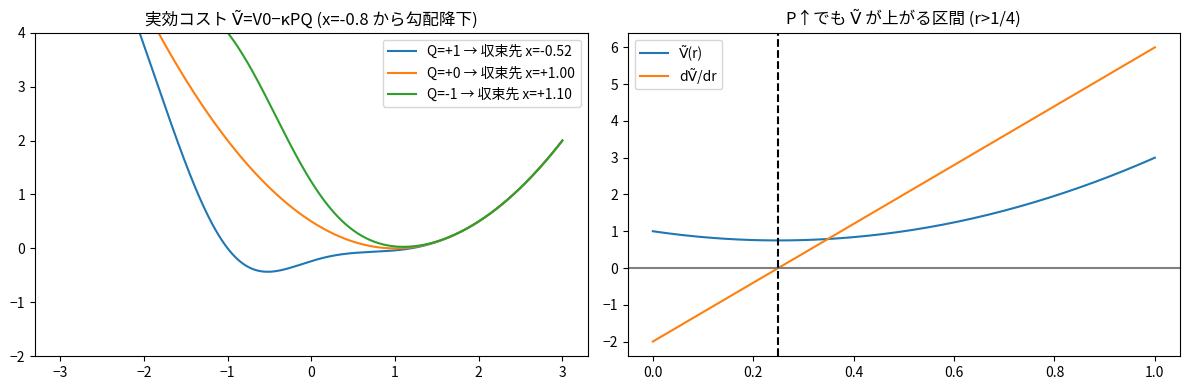

In [3]:
# %% 可視化
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for Q in (+1, 0, -1): ax[0].plot(xs, Vt(xs, Q), label=f"Q={Q:+d} → 収束先 x={ends[Q]:+.2f}")
ax[0].set_title("実効コスト Ṽ=V0−κPQ (x=-0.8 から勾配降下)"); ax[0].legend(); ax[0].set_ylim(-2, 4)
ax[1].plot(r, Vr, label="Ṽ(r)"); ax[1].plot(r, dVr, label="dṼ/dr"); ax[1].axhline(0, c="gray")
ax[1].axvline(0.25, ls="--", c="k"); ax[1].set_title("P↑でも Ṽ が上がる区間 (r>1/4)"); ax[1].legend()
plt.tight_layout(); plt.show()

### 左：実効コスト $\tilde V$

3本の曲線は $Q=+1$（青）、$Q=0$（橙）、$Q=-1$（緑）。
* **橙（$Q=0$、臨場感が効かない素の地形）：** 谷底は $x=+1.00$ ひとつだけ。$x=-0.8$ から降りると右へ進んで $x=+1.00$ に落ち着きます。
* **青（$Q=+1$、引かれる対象）：** $x\approx-0.5$ に **新しい谷** が掘れています（谷底は $\tilde V\approx-0.43$）。$x=-0.8$ から降りると、この **左の谷** に落ち着きます（収束先 $x=-0.52$）。素の谷の底（$x=1$）の付近は、ほとんど変わっていません。
* **緑（$Q=-1$、避ける対象）：** $x=-1$ のまわりが **持ち上がって障壁** になり、左側の谷はなくなります。降りると右へ進み、収束先は $x=+1.10$。素の谷底より少し右にずれています（障壁に押されるため）。

つまり、**同じ出発点、同じ素の地形でも、$P$（どこに臨場感があるか）と $Q$（その価値の符号）で、落ち着き先が変わります**。「夢に臨場感を持てばゴール側に谷ができ、恐怖に臨場感を持てば恐怖側に谷ができる」という原文の説明のとおりです。

### 右：介入 $r$ で $P$ を上げていくとき

青が $\tilde V(r)$、橙が $d\tilde V/dr$、破線が $r=\tfrac14$。
* $r<\tfrac14$：$d\tilde V/dr<0$（橙が $0$ より下）。**$\tilde V$ は下がる。** この間は $Q=1-2r>\tfrac12$ が大きく、$P$ を上げると得をします。
* $r>\tfrac14$：$d\tilde V/dr>0$。**$P$ は増え続けているのに $\tilde V$ は上がります。** $Q=1-2r$ が $r=\tfrac12$ で $0$ になり、その先は負（避けるべき対象）になるからです。$r=1$ では $\tilde V=1+\kappa=3$ まで上がります。

これが但し書きの意味です：**$P$ だけを見て「臨場感を上げれば必ず得」とは言えません。** $Q$ も一緒に動くなら、総変化の符号は追加条件が必要です。

## 6. 数値確認

In [4]:
# %% 数値確認
print({Q: round(float(v), 3) for Q, v in ends.items()})
assert ends[+1] < 0 < ends[-1]                 # Q の符号で行き先が変わる
assert (dVr[r > 0.3] > 0).all() and (dVr[r < 0.2] < 0).all()

{1: -0.522, 0: 1.0, -1: 1.102}


出力は $\{1:-0.522,\ 0:1.0,\ -1:1.102\}$（$Q$ ごとの収束先）。`assert` は、(i) $Q=+1$ の収束先は負で $Q=-1$ の収束先は正（行き先が $Q$ で変わる）、(ii) $r>0.3$ では $d\tilde V/dr>0$、$r<0.2$ では $<0$（符号反転）、を確かめています。

## 7. 仏教的な意義（解釈）

> 原文の説明にそった **思想的な読み** で、Lean で形式化された数理結論そのものではありません。

* **「リアルに感じるものが、地形を掘り直す」。** 原文は、臨場感 $P$ の高い対象は $-\kappa PQ$ のぶんだけ谷を深くし、心の落ち着き先を移す、と説明します。何にリアリティを感じるかが、心がどこへ落ち着くかを決めます。
* **「夢」も「恐怖」も同じ式。** $Q>0$ なら夢（ゴール）の側に谷、$Q<0$ なら恐怖の側が障壁（避ける方向への谷）。同じ数学が両方を説明します。
* **方向づけの定理（20〜22）の入口。** 原文は、定理20〜22を「この一本の式の精密化」と位置づけています。
* ここでは「臨場感」の善悪は問いません。定理4は、**何がどう心を動かすか** の仕組みを述べるだけです。

## 8. Lean との対応

対応ファイル：`Tomabechi/Examples/Theorem4_PresenceWeight.lean`。

| | 内容 | 状態 |
| --- | --- | --- |
| 点ごとの微分 | $\partial\tilde V/\partial P=-\kappa Q$ | 証明済 |
| 介入 $r$ の符号反転 | $d\tilde V/dr$ の閉形式と、$r>\tfrac14$ での正（$\kappa=2$） | 証明済 |
| 臨界点と曲率 | $Q=+1$ では $(-0.6,-0.4)$、$Q=-1$ では $(1,1.5)$ に臨界点がただ一つ（この区間で $\tilde V''>1$）。開始点 $x=-0.8$ より左側でも流れは右向き | 証明済 |
| 連続時間の勾配流（$Q=\pm1$、初期値 $-0.8$） | 大域的な前向き解が存在。臨界点を越えず単調に増え、谷の入口（$Q=+1$：$-0.6$、$Q=-1$：$1$）へ**有限時間**で到達。入口後は局所 PL 評価により、ポテンシャル差と距離が率 $e^{-t}$ 以上で減衰（初期時刻からの形 $Ce^{T}e^{-t}$ も） | 証明済 |
| 閾値 0 の TCZ との関係 | $Q=+1$：勾配流は有限時間で TCZ に入り以後出ない。$Q=-1$：実効ポテンシャルは非負の 2 乗と正のガウスの和なので、**閾値 0 の TCZ は空**（収束は局所最小点へのもので、TCZ への収束ではない） | 証明済 |
| $Q=0$ | 初期値 $-0.8$ からの厳密な閉形式流（誤差が率 1、残差が率 2 で減衰） | 証明済 |
| 上の図 (A) の **Euler 離散軌道・収束先の近似値**（$-0.52,\,+1.10$） | 数値のみ | **未証明** |
| 補題0の前提（一般の非凸ポテンシャルから導く） | このトイの指定モデル以外では未確認 | **未証明** |

* Lean が証明したのは、**指定した一変数モデル・指定初期値 $-0.8$** での連続時間の勾配流です。他の初期値や、図に現れる他の局所最小への落ち込みは証明していません。
* 図 (A) の収束先の数値は、Lean では「臨界点がこの区間にある」ことまでです（正確な値は求めていません）。